# 

# TP S3



## Introduction

Le cloud computing est aujourd’hui au cœur des infrastructures informatiques modernes, et le stockage objet, tel qu’offert par Amazon S3 (Simple Storage Service), est l’un des services les plus utilisés dans ce domaine. Comprendre son fonctionnement et savoir interagir avec S3 par différents moyens est une compétence clé pour tout développeur ou ingénieur cloud.

Ce TP a pour objectif de vous initier de manière progressive et pratique à l’utilisation d’Amazon S3, en explorant plusieurs méthodes d’accès :
* via la console Web AWS,
* la ligne de commande (AWS CLI),
* et l’API Python via la bibliothèque boto3.

Au fil des différentes étapes, vous apprendrez à manipuler les objets stockés dans un bucket S3, à gérer les permissions d’accès, à mettre en œuvre des politiques de rétention et de versionning.

:::{important} Objectif

À l’issue de ce TP, vous serez capables de :
* Créer et gérer des buckets et objets dans S3 via différentes interfaces ;
* Réaliser des opérations CRUD (Create, Read, Update, Delete) sur des objets stockés ;
* Gérer les utilisateurs
* Mettre en place des politiques de conservation (lifecycle) et de versioning
:::

## Pré-requis

Pour ce TP, nous utiliserons MinIO, une solution open source de stockage objet, conçue pour être compatible avec l’API Amazon S3. Cela signifie que toutes les applications, outils ou bibliothèques (comme boto3, aws-cli, s3cmd, etc.) qui fonctionnent avec Amazon S3 peuvent également interagir avec un serveur MinIO, sans modifier le code. 

Pour déployer sur votre machine un container minio, positionner vous dans le répertoire docker et exécuter la commande suivante :

Vérifier que le container minio est bien lancé

si vous analysez le docker-compose.yml vous constaterez 2 publications de ports: 
* Accès Web : http://localhost:9001
* Endpoint S3 : http://localhost:9000

avec le compte admin :
* MINIO_ROOT_USER: minioadmin
* MINIO_ROOT_PASSWORD: minioadmin

Vous êtes à présent prêt pour commencer le TP.

## 1 - Opérations CRUD avec le client AWS 

Pour interragir avec notre API S3 deployé via minio nous allons utiliser un client aws.
Le client aws propose 2 API :
* une API `s3` haut niveau dont la documentation est disponible ici : https://docs.aws.amazon.com/cli/v1/userguide/cli-services-s3-commands.html
* une API `s3api` bas niveau dont la documentation est disponible ici : https://docs.aws.amazon.com/cli/v1/userguide/cli-services-s3-apicommands.html

Pour cela lancer le container awscli de le manière suivante :

Pour interragir depuis notre client awscli vers notre service S3 minio, nous devrons dans un premier temps définir les variables d'environnement AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY et AWS_ENDPOINT_URL.

Nous pouvons à présent utiliser la commande aws pour lister les buckets disponibles :

Cool, ça marche ! sauf que nous n'avons pas encore de buckets ;-)

### Gestion des objets

Notre environnement est configuré pour échanger avec notre service minio S3, en tant qu'admin nous pouvons donc créer des buckets comme on l'entend ;-).

Pour passer à la pratique, vous allez créer dans votre container awscli un fichier `test.txt`.

#### A partir du slide 36 du cours créez les élément suivants : 
* un bucket `envol`
* copier le fichier test.txt dans le bucket envol
* télécharger l'objet test.txt en local sous le nom test_from_s3.txt

Pour lister les objets de votre bucket `envol` utiliser l'option ls :

#### Rappeler l'intérêt des métadonnées ?

Pour associer des métadonnées à un objet on utilisera l'option metadata sous forme de clé=valeur.
Dans l'exemple ci-dessous on définit 3 clés : projet, type, domain

Pour consulter les métadonnées de notre objet :

Vous devriez donc obtenir la sortie standard suivante :

En revanche, il n'est pas possible dans S3 de rechercher ou lister des objets selon leurs métadonnées côté serveur.

#### Pouvez-vous expliquer pourquoi ?


#### A partir du fichier `test.txt` créer un objet dont la clé sera `/stockage/cours/test.txt` dans le bucket `envol` avec les métadonnées `projet=envol,domain=stockage,type=tp`  ?

#### Vérifier que votre objet `stockage/cours/test.txt` a bien été créé ?

#### Que constatez-vous ?

Pour obtenir la liste des objets dont le type est `tp`, on devra donc analyser le header de chaque objet :

Minio fournit une console web pour réaliser les tâches classiques sur un service s3.
Vous pouvez donc consulter et gérer vos objets avec une jolie interface graphique:
http://localhost:9001

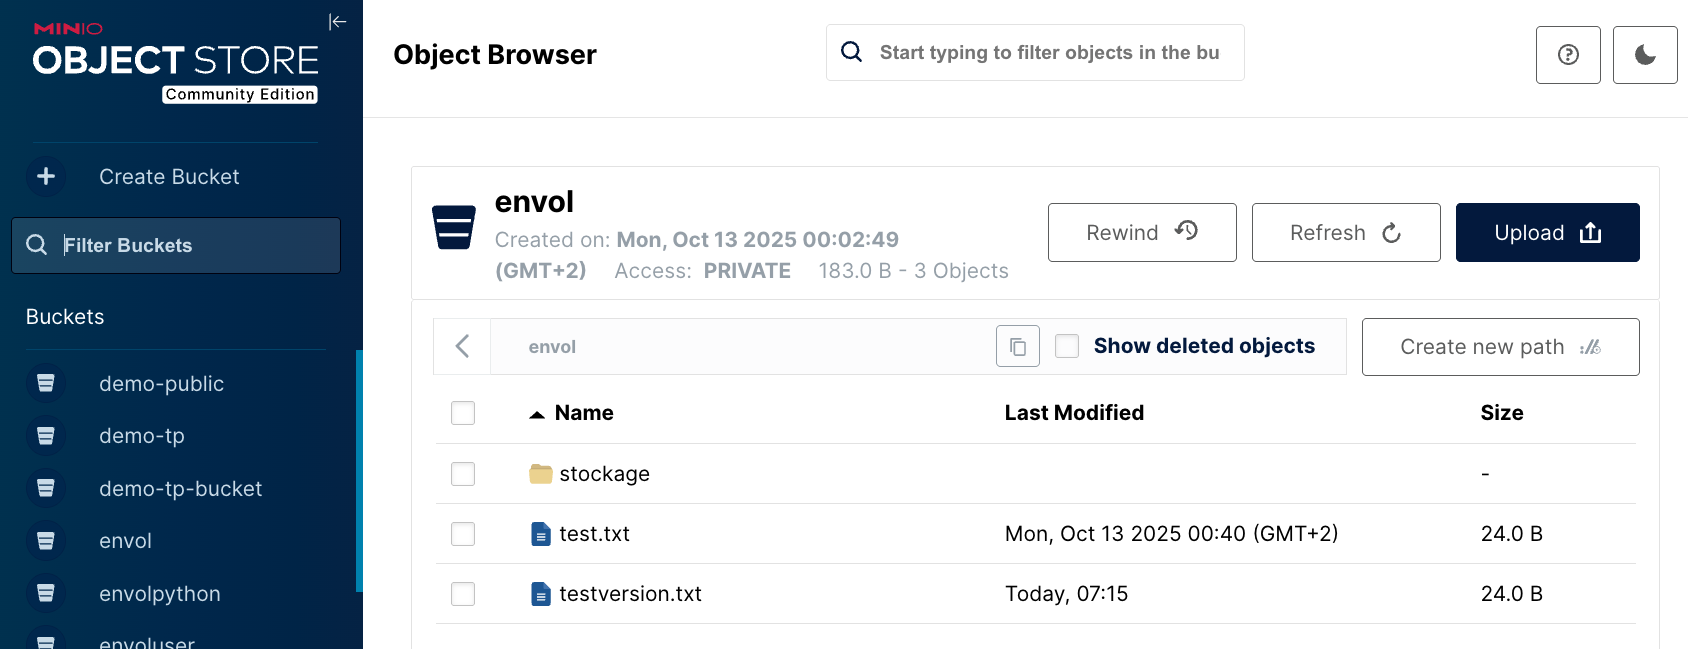

Vous pouvez  supprimer votre objet `test.txt` par la console web ou utiliser votre client aws avec l'option rm :

#### A votre tour supprimer l'objet `stockage/cours/test.txt`

#### Supprimez à présent le bucket `envol` avec l'option rb (remove bucket) ?
```{hint} Indice :
aws s3 rb s3://bucketid
```

Vous pouvez à présent quitter le container aws-cli.

## 2 - Gestion des utilisateurs et des permissions d’accès

Le protocole S3 (utilisé notamment par aws-cli) ne prend pas en charge nativement la gestion des identités (Identity and Access Management).
Cette fonctionnalité est spécifique à AWS, via un service séparé : iam.amazonaws.com. Elle ne fait pas partie du protocole S3 lui-même.
MinIO, bien qu’inspiré d’AWS S3, propose son propre système IAM intégré, compatible avec le modèle AWS, mais exploité via le client mc.

Pour gérer nos utilisateurs (création, permissions, policies…), nous utiliserons le client MinIO (mc), qui est déjà intégré dans notre conteneur MinIO.

Pas d’inquiétude :
* Les commandes de base de mc (comme la gestion des objets ou des buckets) sont très proches de celles d’aws-cli.
* En revanche, les fonctions d’administration (utilisateurs, politiques, etc.) sont spécifiques à mc.
 
Nous allons maintenant démarrer un nouveau conteneur dédié au client mc dans un nouveau terminal pour effectuer les opérations d’administration.

### Création d'un utilisateur

Pour ajouter un utilisateur, on doit accéder aux fonctions d'administration et le client `mc` s'appuie sur un alias (profil) pour gèrer lui-même les connexions et l’authentification.

La création d'un alias est tout simple :

Notre alias `aliasminio` contient nos identifiants de connexion et nous pouvons maintenant administrer notre service minio.

Pour cette section nous allons créer un nouveau bucket `envoluser` avec le client `mc` 

Pour lister les bucket avec `mc`

Créons dans un premier temps un objet dans notre bucket envoluser 

En tant qu'admin, créons un utilisateur `alice`

En consultant le répertoire `/data/.minio.sys/config/iam`, vous devriez voir apparaître notre nouvel utilisateur alice.

### Gestion des permissions

Par défaut, minio dispose déjà de politique / rôle avec un ensemble de permisions.
Pour les lister, on utilisera l'option ls :

Pour voir le détail des permissions d'une politique d'accès (rôle pour les ferrus de BDD) comme `readonly` on pourra utiliser l'option info :

Une politique se compose de déclarations (Statement) qui définissent :
* les actions autorisées ou interdites (ex. : lecture, écriture) ;
* l’effet de la règle (Allow ou Deny) ;
* les ressources concernées (ex. : un bucket ou les objets qu’il contient).

Vous l'aurez compris la politique readonly permet donc à un utilisateur :
* de lire des objets dans n’importe quel bucket,
* de lister les emplacements des buckets,
* mais pas de créer ou supprimer des objets ou des buckets.

```{hint} Information :
Pour les actions :
* s3:GetObject : permet de lire un objet dans un bucket
* s3:GetBucketLocation : permet d’obtenir la région du bucket

La lister des actions est disponible ici : https://docs.min.io/enterprise/aistor-object-store/administration/iam/access/#common-s3-operations
```


Pour permettre à notre nouvel utilisateur `alice` d’accéder au bucket `envoluser`, on va devoir définir notre propre politique d’accès `readonly_envol`.

Voici un exemple de politique qui autorise ("Effect": "Allow") l’utilisateur à :
* lister le contenu du bucket `envoluser` (s3:ListBucket)
* lire les objets contenus dans ce bucket (s3:GetObject)

Elle s’applique à la fois au bucket lui-même ("arn:aws:s3:::envoluser") et à tous ses objets ("arn:aws:s3:::envoluser/*").

Pour appliquer ces nouvelles permissions à notre utilisateur `alice` :
* Créer un fichier readonly_envoluser.json avec le contenu ci-dessus

* Appliquer la policy à alice : https://docs.min.io/enterprise/aistor-object-store/reference/cli/admin/mc-admin-policy/mc-admin-policy-create/

Vérifions les politiques d'accès :

#### A partir de la documentation, affecter la politique readonly_envoluser à notre compte alice :

#### Vérifier avec le client aws-cli que notre compte alice a bien accès à notre bucket ?

:::{hint} Indice
Pour lancer un client aws-cli avec le compte alice vous pouvez exécuter la commande docker suivante : 
```
docker run --rm -it --network docker_bigdata -e AWS_ACCESS_KEY_ID=alice -e AWS_SECRET_ACCESS_KEY=alicepwd -e AWS_ENDPOINT_URL=http://minio:9000 --entrypoint /bin/bash amazon/aws-cli
```
:::

#### Essayer de téléverser un fichier avec le compte alice ?
:::{note} Note
Créer un fichier quelconque :
```
echo ' le fichier de alice' > alice.txt 
:::


Parfait, c'est bien ce qu'on attendait !

Vous pouvez quitter le container aws-cli utilisé pour `alice`.


Dans cette section, vous avez appris à :
* Créer des utilisateurs distincts via le client mc,
* Définir des politiques d’accès (policy), selon le format AWS,
* Assigner des politiques à des utilisateurs pour restreindre ou autoriser certaines actions (lecture, écriture, suppression…),
* Tester les permissions attribuées à chaque utilisateur pour vérifier leur bon fonctionnement.

## 3 - Versioning 

Dans Amazon S3 (ou MinIO), il est possible d’activer le versioning sur un bucket afin de conserver toutes les versions des objets qu’il contient.

Cette fonctionnalité est particulièrement utile en cas :
* d’écrasement accidentel d’un fichier (upload avec le même nom),
* ou de suppression involontaire.

En activant le versioning, chaque modification ou suppression d’un objet crée une nouvelle version, ce qui permet de restaurer des fichiers à tout moment.

```{warning} Attention – Impact du versioning sur le stockage :
Au fil du temps :
* Le nombre de versions par objet peut augmenter,
* Et chaque version occupe de l’espace de stockage facturé comme un objet indépendant.
```

:::{warning} Attention
Pour lancer un client aws-cli à partir du compte minioadmin vous pouvez exécuter la commande docker suivante : 

```
docker run --rm -it --network docker_bigdata -e AWS_ACCESS_KEY_ID=minioadmin -e AWS_SECRET_ACCESS_KEY=minioadmin -e AWS_ENDPOINT_URL=http://minio:9000 --entrypoint /bin/bash amazon/aws-cli
```
:::

Pour cette section, nous utiliserons un bucket `envolversion` que nous allons créer :

Pour activer le versioning dans notre bucket, on modifie la configuration du bucket `--versioning-configuration Status=Enabled`.

On peut vérifier la configuration du versioning pour un bucket avec l'option `get-bucket-versioning`

On peut à présent expérimenter le versionning.
Créons dans un premier temps un objet dans notre bucket envolversion 

On modifie notre objet `testversion.txt` avec le contenu suivant :

Pour lister toutes les versions de l'objet :

Vous devriez obtenir le résultat suivant :


Pour restaurer une version d'un objet, on utilisera l'option copy-object avec la version souhaitée :

Ou vous pouvez aussi utiliser la console web : http://localhost:9001/browser/envolversion/testversion.txt

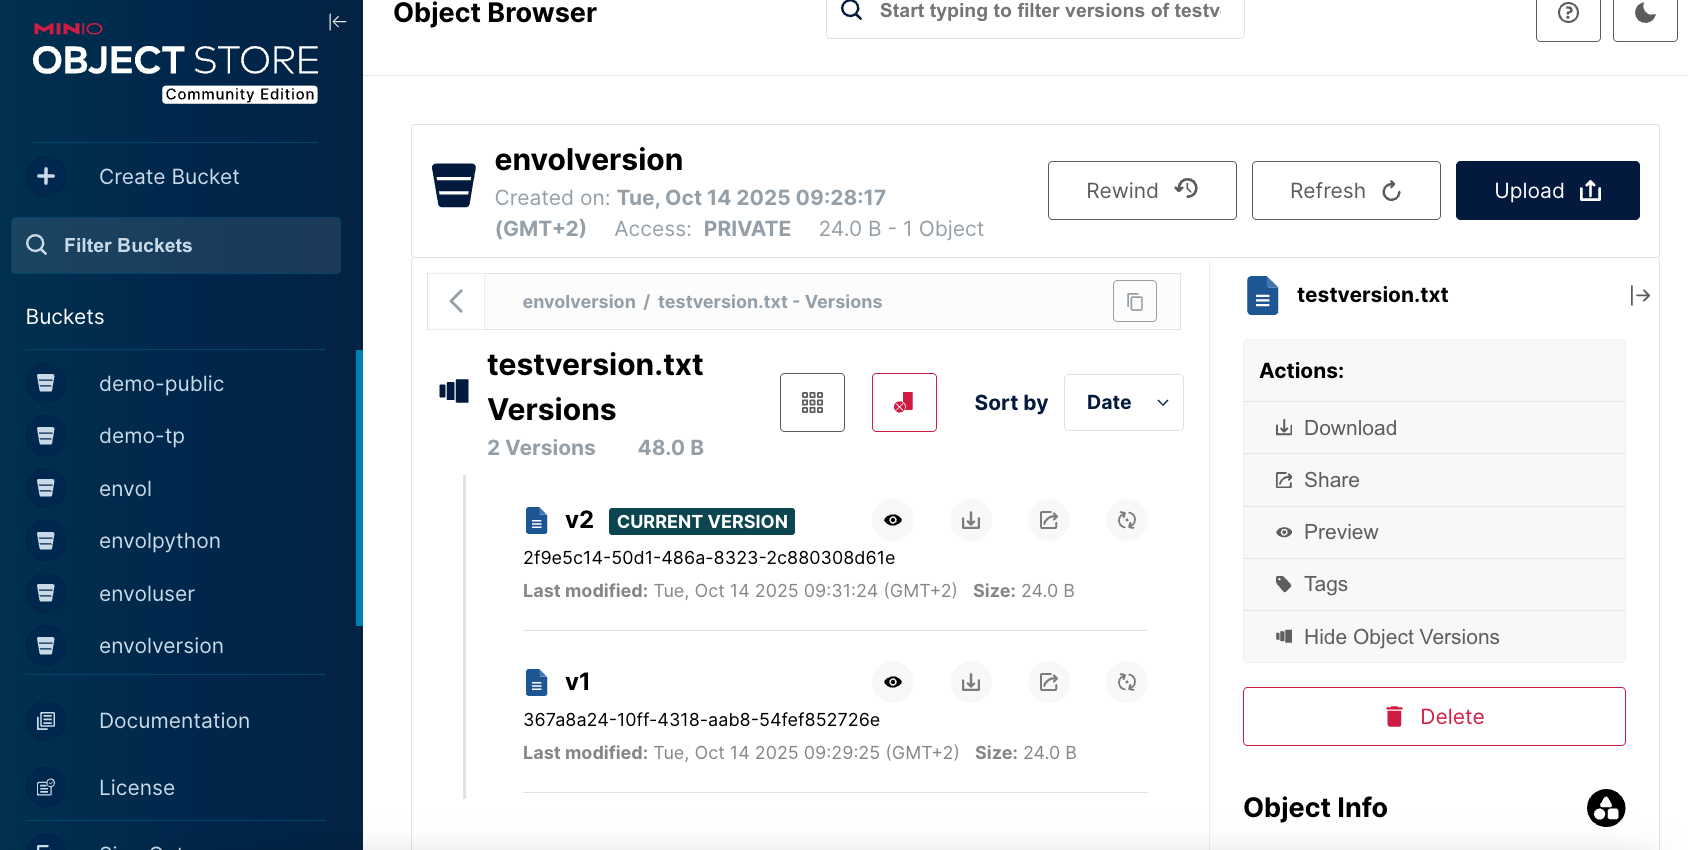

#### Que constatez vous au niveau des versions ?

Dans la précipitation, nous avons oublié d'ajouter nos métadonnées ("projet=envol,domain=stockage,type=tp") à notre objet testversion.txt

#### Pouvez vous les ajouter et que constatez vous sur les versions de l'objet?

#### Supprimer l'objet `testversion.txt` ?

#### Confirmer la suppression de l'objet `testversion.txt` ?

#### Lister à nouveau les versions de l'objet `testversion.txt` ?

#### Que constatez-vous ?

Pour supprimer toutes les versions associées à un objet, il faudra donc procéder à la suppression de chacune d'entre elles :

Procéder à la suppression de tous les objets 

Vous pouvez à présent fermer votre aws-cli.

## 4 - Politique de rétention 

Dans un bucket versionné, chaque modification ou suppression d’objet génère une nouvelle version.
Si aucun nettoyage n’est mis en place, l’espace consommé peut augmenter de manière importante.

Pour y remédier, on peut définir une politique de cycle de vie, qui automatise la suppression d’objets ou de versions selon leur âge.

La documentation relatif à l'expression de la politique de gestion des objets est disponible ici : https://docs.aws.amazon.com/AmazonS3/latest/userguide/lifecycle-configuration-examples.html

De manière plus générale, le Lifecycle (ou cycle de vie) est une fonctionnalité native de l’API S3 qui permet d’automatiser des actions sur les objets stockés dans un bucket en fonction de leur âge. Il s’agit d’un outil essentiel pour :
* Réduire les coûts de stockage en supprimant ou archivant des objets automatiquement,
* Gérer la durée de vie des données (temporaire, archivage, rotation…),
* Appliquer des politiques de rétention automatisées sans intervention manuelle.

Un document de lifecycle est un fichier JSON/XML qui contient une ou plusieurs règles. Chaque règle définit :

* ID :Identifiant de la règle
* Status : Enabled ou Disabled
* Prefix / Filter : Cible les objets concernés
* Expiration : Action à appliquer (suppression ou archivage)
* Transition : Passage à une classe de stockage plus froide (AWS uniquement)

Pour mettre en place un lifecycle nous utiliserons le compte adminminio 

Dans cette section, nous travaillerons avec un nouveau bucket `envollifecycle` avec le versioning activé .

#### avec le client aws créer le bucket `envollifecycle`? 

Créons des objets pour avoir des versions différentes d'objets :

Pour appliquer une gestion de vie des objets nous allons créer un fichier lifecycle.json qui décrit notre politique :

Ce document contient deux règles activées ("Status": "Enabled") et appliquées à tous les objets ("Prefix": "" signifie “tout le bucket”).



Cette règle s’applique aux objets versionnés.
* Elle supprime automatiquement les anciennes versions d’un objet après 7 jours.
* Cela permet de garder uniquement la version courante, tout en laissant un délai de 7 jours avant de supprimer les versions obsolètes.


Cette règle s’applique à tous les objets normaux (même sans versionnement).
* Elle supprime les objets 30 jours après leur création.
* C’est une stratégie utile pour éviter l’accumulation de fichiers anciens, surtout dans des buckets “temporaire”, “logs”, etc.

Pour définir vos propres règles de gestion de vie consulter la documentation sur l'API S3 : https://docs.aws.amazon.com/AmazonS3/latest/userguide/intro-lifecycle-rules.html


L'application d'une lifecyle se réalise avec la commande suivante :


Pour vérifier la politique de lifecycle de notre bucket `envollifecycle`:

Les règles de lifecycle fonctionnent uniquement avec une granularité en jours (pas de suppression à l’heure ou à la minute) ce qui est plutôt logique. Il ne sera donc pas possible de voir l'application des régles dans l'immédiat.

Au final, la gestion du cycle de vie (lifecycle) est une fonctionnalité puissante qui permet d’automatiser la suppression ou l’archivage des objets stockés dans un bucket, selon leur ancienneté ou leur version.

Le cycle de vie permet de :
* Optimiser l’espace de stockage,
* Réduire les coûts en supprimant automatiquement les données inutiles,
* Automatiser la gouvernance des données, notamment dans les buckets à usage temporaire (fichiers logs, backups, traitements éphémères…).
 

## 5 - Le SDK Python pour AWS

Pour interagir facilement avec des services cloud depuis un langage de programmation, sans avoir à gérer les complexités techniques des appels d’API, on utilise généralement des SDK.

Un SDK (Software Development Kit) est un ensemble d’outils fournis par un prestataire cloud (comme AWS, Google ou MinIO) pour simplifier l’utilisation de ses services dans un langage donné. Il offre une interface de haut niveau qui permet de manipuler ces services comme s’ils faisaient partie intégrante du langage.

Dans l’écosystème AWS, le SDK officiel pour Python s’appelle boto3.
Il permet aux développeurs d’accéder à tous les services AWS – notamment S3 – de manière simple et intuitive, directement depuis leurs scripts ou applications Python.

On peut considérer boto3 comme l’équivalent programmatique de la ligne de commande aws-cli, mais avec toute la puissance et la flexibilité de Python.

On peut donc: 
* Automatiser les tâches cloud (ex. : upload, backup, gestion de buckets)
* Créer des applications cloud natives (upload user files, logs…)
* Gérer IAM, policies, lifecycle, versioning…
* Compatible avec tous les services S3-compatible

On va donc procéder à l'installation de boto3 dans notre notebook jupyter :

In [2]:
pip install boto3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 2.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 11.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 7.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


Le détail de la bibliothèque boto3 est disponible à l'url suivante :
https://boto3.amazonaws.com/v1/documentation/api/latest/index.html


Notre serveur `minio`est actif, il ne reste plus qu'à initialiser la connexion :

In [3]:
import boto3
from botocore.exceptions import ClientError

# === Configuration MinIO (ou AWS) ===
S3_ENDPOINT = 'http://minio:9000'
ACCESS_KEY = 'minioadmin'
SECRET_KEY = 'minioadmin'
REGION = 'eu-east-1' # Le nom de la région est facultatif avec minio mais nécessaire pour les services AWS S3


# === Connexion au service S3 ===
s3 = boto3.client('s3',
                  endpoint_url=S3_ENDPOINT,
                  aws_access_key_id=ACCESS_KEY,
                  aws_secret_access_key=SECRET_KEY,
                  region_name=REGION)


Pour tester notre connexion, nous allons lister les buckets :

In [4]:
# Tester la connexion
response = s3.list_buckets()
print("Buckets disponibles :")
for bucket in response["Buckets"]:
    print("-", bucket["Name"])

Buckets disponibles :
- envollifecycle
- envoluser
- envolversion


Cool !

### Création d'un bucket

Créons à présent un nouveau bucket `envolpython`


In [5]:
bucket = 'envolpython'

def create_bucket(bucket_name):
    try:
        s3.create_bucket(Bucket=bucket_name)
        print(f"[+] Bucket créé : {bucket_name}")
    except ClientError as e:
        print(f"[!] Erreur création bucket : {e.response['Error']['Message']}")

In [6]:
print("\n--- 1. Créer & lister les buckets ---")
create_bucket(bucket)



--- 1. Créer & lister les buckets ---
[+] Bucket créé : envolpython


### Pour afficher tous les buckets disponibles :

In [7]:
def list_buckets():
    response = s3.list_buckets()
    print("[=] Liste des buckets :")
    for bucket in response['Buckets']:
        print(f" - {bucket['Name']}")

In [8]:
list_buckets()

[=] Liste des buckets :
 - envollifecycle
 - envolpython
 - envoluser
 - envolversion


### Pour envoyer un fichier

In [56]:
!echo 'Bonjour depuis Python !' > bonjour.txt

In [53]:
def upload_object(bucket_name, object_name,extra={}):
    try:     
        s3.upload_file(Filename=object_name, Bucket=bucket_name, Key=object_name, ExtraArgs=extra)
        print(f"[+] Objet '{object_name}' créé dans le bucket '{bucket_name}'")
    except ClientError as e:
        print(f"[!] Erreur upload : {e.response['Error']['Message']}")

In [60]:
objet = 'bonjour.txt'
print("\n--- 2. Créer un objet ---")
upload_object(bucket, objet)



--- 2. Créer un objet & lister les objets ---
[+] Objet 'bonjour.txt' créé dans le bucket 'envolpython'


In [ ]:
Pour ajouter des métadonnées :

In [68]:
objet = 'bonjour.txt'
metadata = {
    "Metadata": {
        "projet": "TP-S3",
        "auteur": "alice"
    }
}

print("\n--- 2. Créer un objet avec meta---")

upload_object(bucket, objet,metadata)



--- 2. Créer un objet avec meta---
[+] Objet 'bonjour.txt' créé dans le bucket 'envolpython'


Pour lire les métadonnées : 

In [69]:
resp = s3.head_object(Bucket=bucket, Key=objet)
print("Métadonnées attachées :", resp["Metadata"])

Métadonnées attachées : {'auteur': 'alice', 'projet': 'TP-S3'}


Pour lister les objets d'un bucket


In [61]:
def list_objects(bucket_name):
    try:
        response = s3.list_objects_v2(Bucket=bucket_name)
        print(f"[=] Objets dans '{bucket_name}':")
        if 'Contents' in response:
            for obj in response['Contents']:
                print(f" - {obj['Key']}")
        else:
            print(" (aucun objet)")
    except ClientError as e:
        print(f"[!] Erreur listing objets : {e.response['Error']['Message']}")

In [62]:
list_objects(bucket)

[=] Objets dans 'envolpython':
 - bonjour.txt
 - bonjour2.txt


Pour télécharger un objet :

In [50]:
def download_object(bucket_name, object_key, destination_path):
    try:
        s3.download_file(bucket_name, object_key, destination_path)
        print(f"✅ Objet téléchargé dans : {destination_path}")
    except (BotoCoreError, ClientError) as e:
        print(f"❌ Erreur lors du téléchargement : {e}")

In [58]:
bucket = 'envolpython'
object_key = 'bonjour2.txt'
destination_path='./bonjour2_from_s3.txt'

download_object(bucket, objet, destination_path)

✅ Objet téléchargé dans : ./bonjour2_from_s3.txt


### Pour supprimer un objet

In [14]:
def delete_object(bucket_name, object_name):
    try:
        s3.delete_object(Bucket=bucket_name, Key=object_name)
        print(f"[-] Objet '{object_name}' supprimé du bucket '{bucket_name}'")
    except ClientError as e:
        print(f"[!] Erreur suppression : {e.response['Error']['Message']}")

In [15]:
    print("\n--- 3. Supprimer l'objet ---")
    delete_object(bucket, objet)
    list_objects(bucket)


--- 3. Supprimer l'objet ---
[-] Objet 'bonjour.txt' supprimé du bucket 'envolpython'
[=] Objets dans 'envolpython':
 (aucun objet)


L’utilisation d’un SDK comme boto3 facilite grandement l’interaction avec des services cloud tels que S3. Plutôt que de manipuler directement les requêtes HTTP ou l’API REST, le SDK offre une interface de haut niveau, intuitive et adaptée au langage utilisé – ici, Python.

Grâce à boto3, nous avons pu :
* Se connecter facilement à un service S3 (AWS ou MinIO),
* Gérer des opérations de stockage (création de bucket, upload, téléchargement, suppression…),

Il est bien entendu aussi possible d'automatiser des tâches avancées comme le versionnement ou le cycle de vie des objets.

# Conclusion

Le stockage S3 n’est pas qu’un simple espace de fichiers : c’est un composant fondamental des architectures cloud modernes, alliant souplesse, résilience et automatisation.

En apprenant à le manipuler via l’API ou des SDK, vous développez des compétences réutilisables dans tout environnement cloud ou DevOps, que ce soit en local ou à l’échelle d’une infrastructure cloud complète.